In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [2]:
np.random.seed(1)

#### Longitudinal Learning

In [3]:
# Simulation parameters

n_participants = 30
n_sessions = 12

population_intercept = 700
population_slope = -18

intercept_sd = 60
slope_sd = 5
residual_sd = 25

In [4]:
# Simulating participant-specific parameters.

participant_intercepts = np.random.normal(
    population_intercept,
    intercept_sd,
    n_participants,
)

participant_slopes = np.random.normal(
    population_slope,
    slope_sd,
    n_participants,
)

In [5]:
# Simulating longitudinal dataset.

data = []

for participant in range(n_participants):

    intercept = participant_intercepts[participant]
    slope = participant_slopes[participant]

    for session in range(1, n_sessions + 1):

        reaction_time = (
            intercept
            + slope * session
            + np.random.normal(0, residual_sd)
        )

        data.append(
            [
                participant,
                session,
                reaction_time,
            ]
        )

longitudinal_data = pd.DataFrame(
    data,
    columns=[
        "participant",
        "session",
        "reaction_time",
    ],
)

In [6]:
# Summary statistics

print("Longitudinal dataset\n")
print(longitudinal_data.describe())

print(
    "\nNumber of participants:",
    longitudinal_data["participant"].nunique(),
)

print(
    "Sessions per participant:",
    n_sessions,
)

Longitudinal dataset

       participant     session  reaction_time
count   360.000000  360.000000     360.000000
mean     14.500000    6.500000     583.019802
std       8.667488    3.456857      90.973668
min       0.000000    1.000000     315.514329
25%       7.000000    3.750000     525.039082
50%      14.500000    6.500000     586.985115
75%      22.000000    9.250000     648.841975
max      29.000000   12.000000     785.865818

Number of participants: 30
Sessions per participant: 12


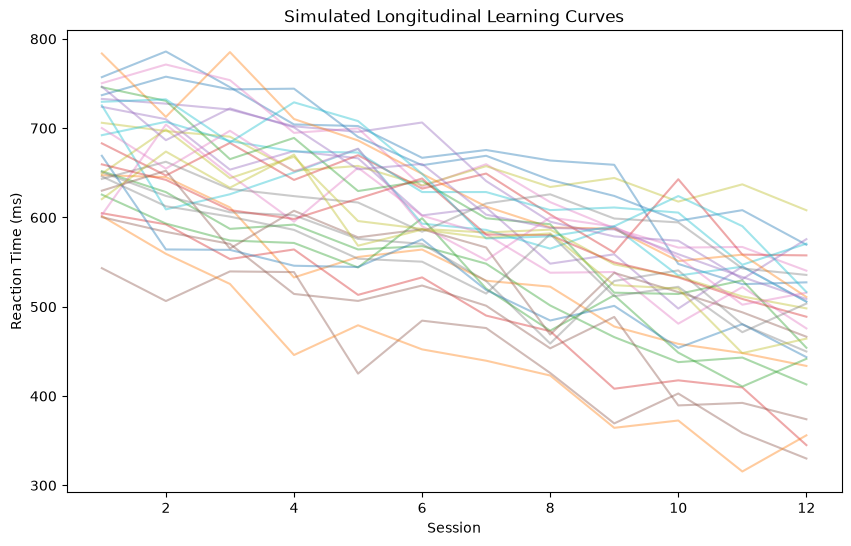

In [8]:
# Visualizing individual learning curves.

plt.figure(figsize=(10, 6))

for participant in longitudinal_data["participant"].unique():

    participant_data = longitudinal_data[
        longitudinal_data["participant"] == participant
    ]

    plt.plot(
        participant_data["session"],
        participant_data["reaction_time"],
        alpha=0.4,
    )

plt.xlabel("Session")
plt.ylabel("Reaction Time (ms)")
plt.title("Simulated Longitudinal Learning Curves")

plt.show()

In [10]:
# Fitting random intercept model.

random_intercept_model = smf.mixedlm(
    "reaction_time ~ session",
    data=longitudinal_data,
    groups="participant",
)

random_intercept_results = random_intercept_model.fit()

print("Random intercept model\n")
print(random_intercept_results.summary())

Random intercept model

             Mixed Linear Model Regression Results
Model:              MixedLM  Dependent Variable:  reaction_time
No. Observations:   360      Method:              REML         
No. Groups:         30       Scale:               815.9856     
Min. group size:    12       Log-Likelihood:      -1773.8000   
Max. group size:    12       Converged:           Yes          
Mean group size:    12.0                                       
---------------------------------------------------------------
                 Coef.   Std.Err.    z    P>|z|  [0.025  0.975]
---------------------------------------------------------------
Intercept        698.554   11.708  59.662 0.000 675.605 721.502
session          -17.774    0.436 -40.755 0.000 -18.629 -16.920
participant Var 3803.570   37.127                              



In [11]:
# Fitting random intercept and slope model.

random_slope_model = smf.mixedlm(
    "reaction_time ~ session",
    data=longitudinal_data,
    groups="participant",
    re_formula="~session",
)

random_slope_results = random_slope_model.fit()

print("Random intercept and slope model\n")
print(random_slope_results.summary())


Random intercept and slope model

                  Mixed Linear Model Regression Results
Model:                  MixedLM     Dependent Variable:     reaction_time
No. Observations:       360         Method:                 REML         
No. Groups:             30          Scale:                  638.5117     
Min. group size:        12          Log-Likelihood:         -1753.6249   
Max. group size:        12          Converged:              Yes          
Mean group size:        12.0                                             
-------------------------------------------------------------------------
                           Coef.   Std.Err.    z    P>|z|  [0.025  0.975]
-------------------------------------------------------------------------
Intercept                  698.554   11.588  60.283 0.000 675.842 721.266
session                    -17.774    0.786 -22.607 0.000 -19.315 -16.233
participant Var           3786.554   43.844                              
participant x session 

In [12]:
# Population-level Predictions

prediction_data = pd.DataFrame(
    {
        "session": np.arange(1, n_sessions + 1),
    }
)

prediction_data["predicted_rt"] = (
    random_slope_results.predict(prediction_data)
)

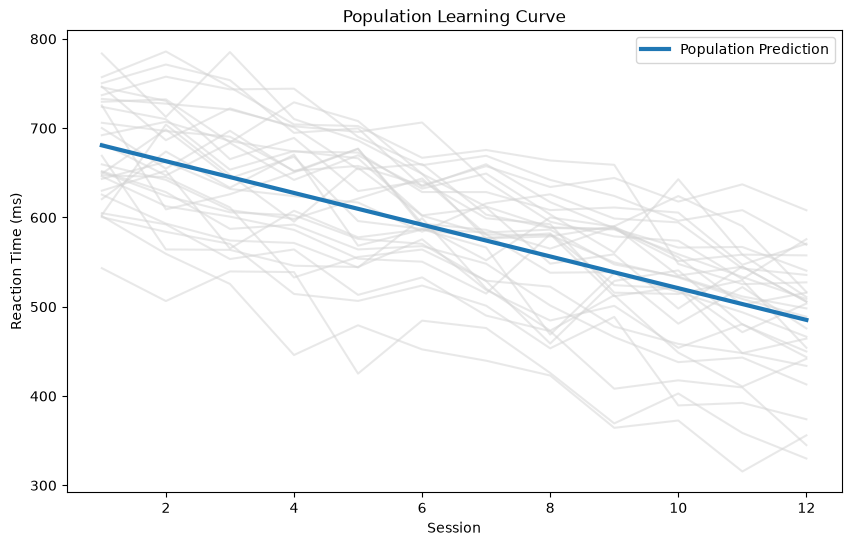

In [13]:
# Visualizing observed trajectories with population prediction.

plt.figure(figsize=(10, 6))

for participant in longitudinal_data["participant"].unique():

    participant_data = longitudinal_data[
        longitudinal_data["participant"] == participant
    ]

    plt.plot(
        participant_data["session"],
        participant_data["reaction_time"],
        color="lightgray",
        alpha=0.5,
    )

plt.plot(
    prediction_data["session"],
    prediction_data["predicted_rt"],
    linewidth=3,
    label="Population Prediction",
)

plt.xlabel("Session")
plt.ylabel("Reaction Time (ms)")
plt.title("Population Learning Curve")

plt.legend()

plt.show()

#### Accuracy Data (Logistic Regression)

In [14]:
# Simulation parameters

n_participants = 40
n_trials = 80

participant_intercepts = np.random.normal(0, 0.8, n_participants)

# Simulating accuracy data.

accuracy_data = []

for participant in range(n_participants):

    intercept = participant_intercepts[participant]

    for trial in range(n_trials):

        condition = np.random.choice(
            ["Easy", "Hard"],
        )

        x = 0 if condition == "Easy" else 1

        logit = intercept - 1.2 * x

        probability = 1 / (1 + np.exp(-logit))

        accuracy = np.random.binomial(1, probability)

        accuracy_data.append(
            [
                participant,
                condition,
                accuracy,
            ]
        )

accuracy_data = pd.DataFrame(
    accuracy_data,
    columns=[
        "participant",
        "condition",
        "accuracy",
    ],
)

In [15]:
# Summary statistics

print("Accuracy dataset\n", accuracy_data.head())

print("\nAccuracy by condition\n", accuracy_data.groupby("condition")["accuracy"].mean())

print(
    "\nNumber of participants:",
    accuracy_data["participant"].nunique(),
)

print(
    "Trials per participant:",
    n_trials,
)

Accuracy dataset
    participant condition  accuracy
0            0      Hard         0
1            0      Hard         0
2            0      Easy         1
3            0      Easy         1
4            0      Easy         0

Accuracy by condition
 condition
Easy    0.530197
Hard    0.282729
Name: accuracy, dtype: float64

Number of participants: 40
Trials per participant: 80


In [22]:
# Logistic Regression

accuracy_model = smf.glm(
    "accuracy ~ C(condition)",
    data=accuracy_data,
    family=sm.families.Binomial(),
).fit()

print("Logistic regression\n", accuracy_model.summary())

Logistic regression
                  Generalized Linear Model Regression Results                  
Dep. Variable:               accuracy   No. Observations:                 3200
Model:                            GLM   Df Residuals:                     3198
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2056.3
Date:                Mon, 20 Jul 2026   Deviance:                       4112.7
Time:                        17:03:04   Pearson chi2:                 3.20e+03
No. Iterations:                     4   Pseudo R-squ. (CS):            0.06225
Covariance Type:            nonrobust                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept  

#### Choice Data (Logistic Regression)

In [24]:
# Simulation parameters

n_participants = 40
n_trials = 100

participant_bias = np.random.normal(0, 0.7, n_participants)

# Simulating choice data.

choice_data = []

for participant in range(n_participants):

    bias = participant_bias[participant]

    for trial in range(n_trials):

        stimulus_strength = np.random.normal(0, 1)

        logit = (
            bias
            + 1.5 * stimulus_strength
        )

        probability = 1 / (1 + np.exp(-logit))

        choice = np.random.binomial(
            1,
            probability,
        )

        choice_data.append(
            [
                participant,
                stimulus_strength,
                choice,
            ]
        )

choice_data = pd.DataFrame(
    choice_data,
    columns=[
        "participant",
        "stimulus_strength",
        "choice",
    ],
)

In [31]:
# Summary statistics

print("Choice dataset\n", choice_data.head())

print("\nChoice proportions\n", choice_data["choice"].value_counts(normalize=True))

print("\nNumber of participants:", choice_data["participant"].nunique(),)

print("Trials per participant:", n_trials,)

Choice dataset
    participant  stimulus_strength  choice
0            0           0.776535       1
1            0           0.003154       0
2            0          -0.046168       1
3            0          -0.744312       1
4            0          -1.650243       0

Choice proportions
 choice
1    0.5105
0    0.4895
Name: proportion, dtype: float64

Number of participants: 40
Trials per participant: 40


In [27]:
# Logistic Regression

choice_model = smf.glm(
    "choice ~ stimulus_strength",
    data=choice_data,
    family=sm.families.Binomial(),
).fit()

print("Logistic regression\n", choice_model.summary())

Logistic regression
                  Generalized Linear Model Regression Results                  
Dep. Variable:                 choice   No. Observations:                 4000
Model:                            GLM   Df Residuals:                     3998
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2195.4
Date:                Mon, 20 Jul 2026   Deviance:                       4390.7
Time:                        17:04:51   Pearson chi2:                 3.90e+03
No. Iterations:                     5   Pseudo R-squ. (CS):             0.2504
Covariance Type:            nonrobust                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept        

#### Count Data (Poisson Regression)

In [28]:
# Simulation parameters

n_participants = 35
n_trials = 40

participant_intercepts = np.random.normal(
    1.5,
    0.4,
    n_participants,
)

# Simulating count data.

count_data = []

for participant in range(n_participants):

    intercept = participant_intercepts[participant]

    for trial in range(n_trials):

        condition = np.random.choice(
            ["Control", "Treatment"],
        )

        x = 0 if condition == "Control" else 1

        log_rate = (
            intercept
            + 0.35 * x
        )

        rate = np.exp(log_rate)

        count = np.random.poisson(rate)

        count_data.append(
            [
                participant,
                condition,
                count,
            ]
        )

count_data = pd.DataFrame(
    count_data,
    columns=[
        "participant",
        "condition",
        "count",
    ],
)

In [30]:
# Summary statistics

print("Count dataset\n", count_data.head())

print("\nCounts by condition\n", count_data.groupby("condition")["count"].describe())

print("\nNumber of participants:", count_data["participant"].nunique(),)

print("Trials per participant:", n_trials,)

Count dataset
    participant  condition  count
0            0  Treatment      4
1            0    Control      5
2            0    Control      3
3            0    Control      2
4            0    Control      1

Counts by condition
            count      mean       std  min  25%  50%  75%   max
condition                                                     
Control    660.0  4.275758  2.676774  0.0  2.0  4.0  6.0  15.0
Treatment  740.0  6.421622  3.769124  0.0  4.0  6.0  8.0  26.0

Number of participants: 35
Trials per participant: 40


In [34]:
# Poisson Regression

count_model = smf.glm(
    "count ~ C(condition)",
    data=count_data,
    family=sm.families.Poisson(),
).fit()

print("Poisson regression\n", count_model.summary())

Poisson regression
                  Generalized Linear Model Regression Results                  
Dep. Variable:                  count   No. Observations:                 1400
Model:                            GLM   Df Residuals:                     1398
Model Family:                 Poisson   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3695.2
Date:                Mon, 20 Jul 2026   Deviance:                       2749.9
Time:                        17:18:58   Pearson chi2:                 2.74e+03
No. Iterations:                     4   Pseudo R-squ. (CS):             0.1936
Covariance Type:            nonrobust                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
In